# 🏥 Hospital Bottleneck Analysis
## EDA · Statistical Testing · Machine Learning

**Dataset:** 120K admissions · 86.4K patients · 33 hospitals · 5 relational tables  
**Goal:** Identify delays, overload patterns, and inefficiencies using data science.

---
### Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Capacity & Occupancy Analysis](#3)
4. [Length of Stay (LOS) Deep Dive](#4)
5. [Readmission Analysis](#5)
6. [Financial / Billing Analysis](#6)
7. [Statistical Hypothesis Testing](#7)
8. [Machine Learning — LOS Prediction](#8)
9. [Machine Learning — Readmission Risk Score](#9)
10. [Clustering — Patient Segmentation](#10)
11. [Summary of Bottlenecks](#11)

## 1. Setup & Data Loading <a id='1'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, shapiro
import warnings
warnings.filterwarnings('ignore')

# ── plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
PALETTE = {'ICU':'#E24B4A','NICU':'#c0392b','HDU':'#EF9F27','General':'#1D9E75'}
print('Libraries loaded ✓')

Libraries loaded ✓


In [42]:
# ── Load all 5 tables ─────────────────────────────────────────────────────────
adm  = pd.read_csv('admissions.csv',  parse_dates=['admit_date','discharge_date'])
bill = pd.read_csv('billing.csv')
diag = pd.read_csv('diagnoses.csv')
hosp = pd.read_csv('hospitals.csv')
pat  = pd.read_csv('patients.csv')

print(f'Admissions : {adm.shape}')
print(f'Billing    : {bill.shape}')
print(f'Diagnoses  : {diag.shape}')
print(f'Hospitals  : {hosp.shape}')
print(f'Patients   : {pat.shape}')

Admissions : (120000, 17)
Billing    : (120000, 6)
Diagnoses  : (271341, 6)
Hospitals  : (33, 6)
Patients   : (86400, 8)


In [43]:
# ── Build master merged dataframe ─────────────────────────────────────────────
bill_agg = (bill.groupby('admission_id')
                .agg(total_cost     = ('total_cost_inr','sum'),
                     oop_cost       = ('out_of_pocket_inr','sum'),
                     subsidy        = ('govt_subsidy_inr','sum'))
                .reset_index())

df = (adm
      .merge(pat,      on='patient_id',   how='left')
      .merge(hosp,     on='hospital_id',  how='left')
      .merge(bill_agg, on='admission_id', how='left'))

df['admit_year']  = df['admit_date'].dt.year
df['admit_month'] = df['admit_date'].dt.month
df['admit_dow']   = df['admit_date'].dt.dayofweek   # 0=Mon
df['admit_dow_name'] = df['admit_date'].dt.day_name()
df['age_band'] = pd.cut(df['age'], bins=[0,18,35,50,65,120],
                        labels=['0-18','19-35','36-50','51-65','65+'])

print(f'Master df: {df.shape}')
df.head(3)

Master df: (120000, 37)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,...,beds,teaching,total_cost,oop_cost,subsidy,admit_year,admit_month,admit_dow,admit_dow_name,age_band
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,...,359,True,18492,1862,16630,2024,1,1,Tuesday,36-50
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,67,False,1001,1001,0,2019,11,0,Monday,19-35
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,...,1018,True,59696,11046,48650,2019,11,4,Friday,51-65


## 2. Exploratory Data Analysis (EDA) <a id='2'></a>

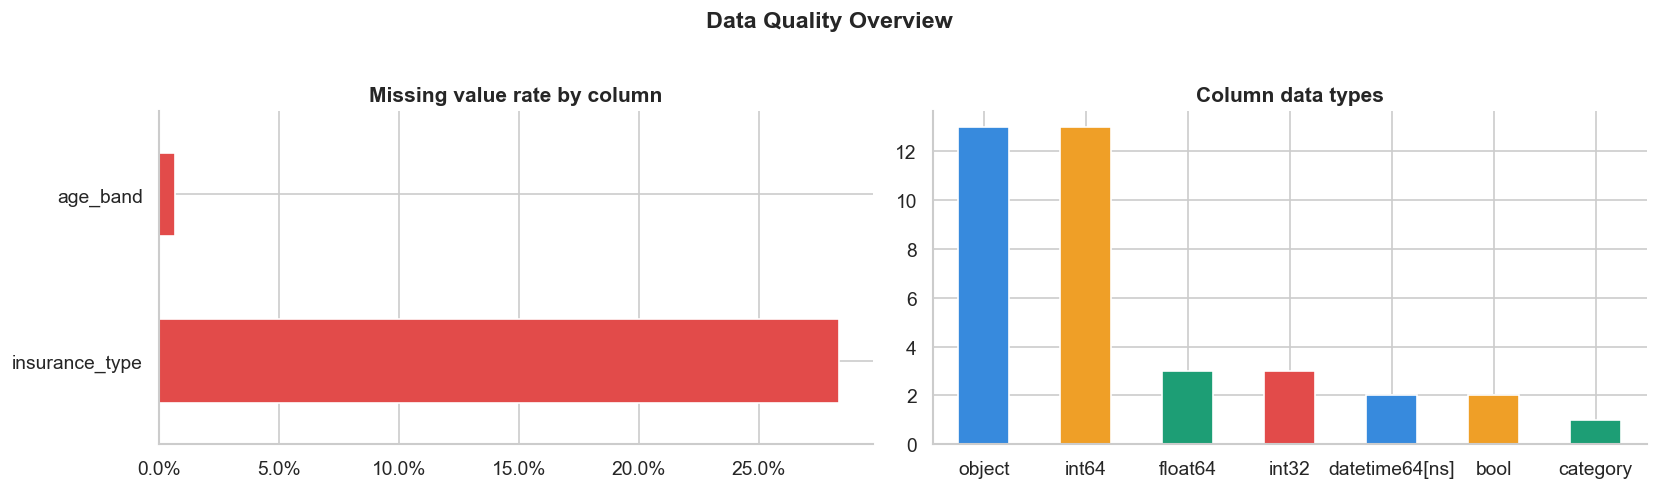

In [44]:
# ── Missing values heatmap ────────────────────────────────────────────────────
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if len(miss) > 0:
    miss.plot(kind='barh', ax=axes[0], color='#E24B4A')
    axes[0].set_title('Missing value rate by column', fontweight='bold')
    axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
else:
    axes[0].text(0.5, 0.5, 'No missing values!', ha='center', va='center',
                 fontsize=14, color='green', transform=axes[0].transAxes)
    axes[0].set_title('Missing values', fontweight='bold')

# Data types overview
dtype_counts = df.dtypes.astype(str).value_counts()
dtype_counts.plot(kind='bar', ax=axes[1], color=['#378ADD','#EF9F27','#1D9E75','#E24B4A'])
axes[1].set_title('Column data types', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Data Quality Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

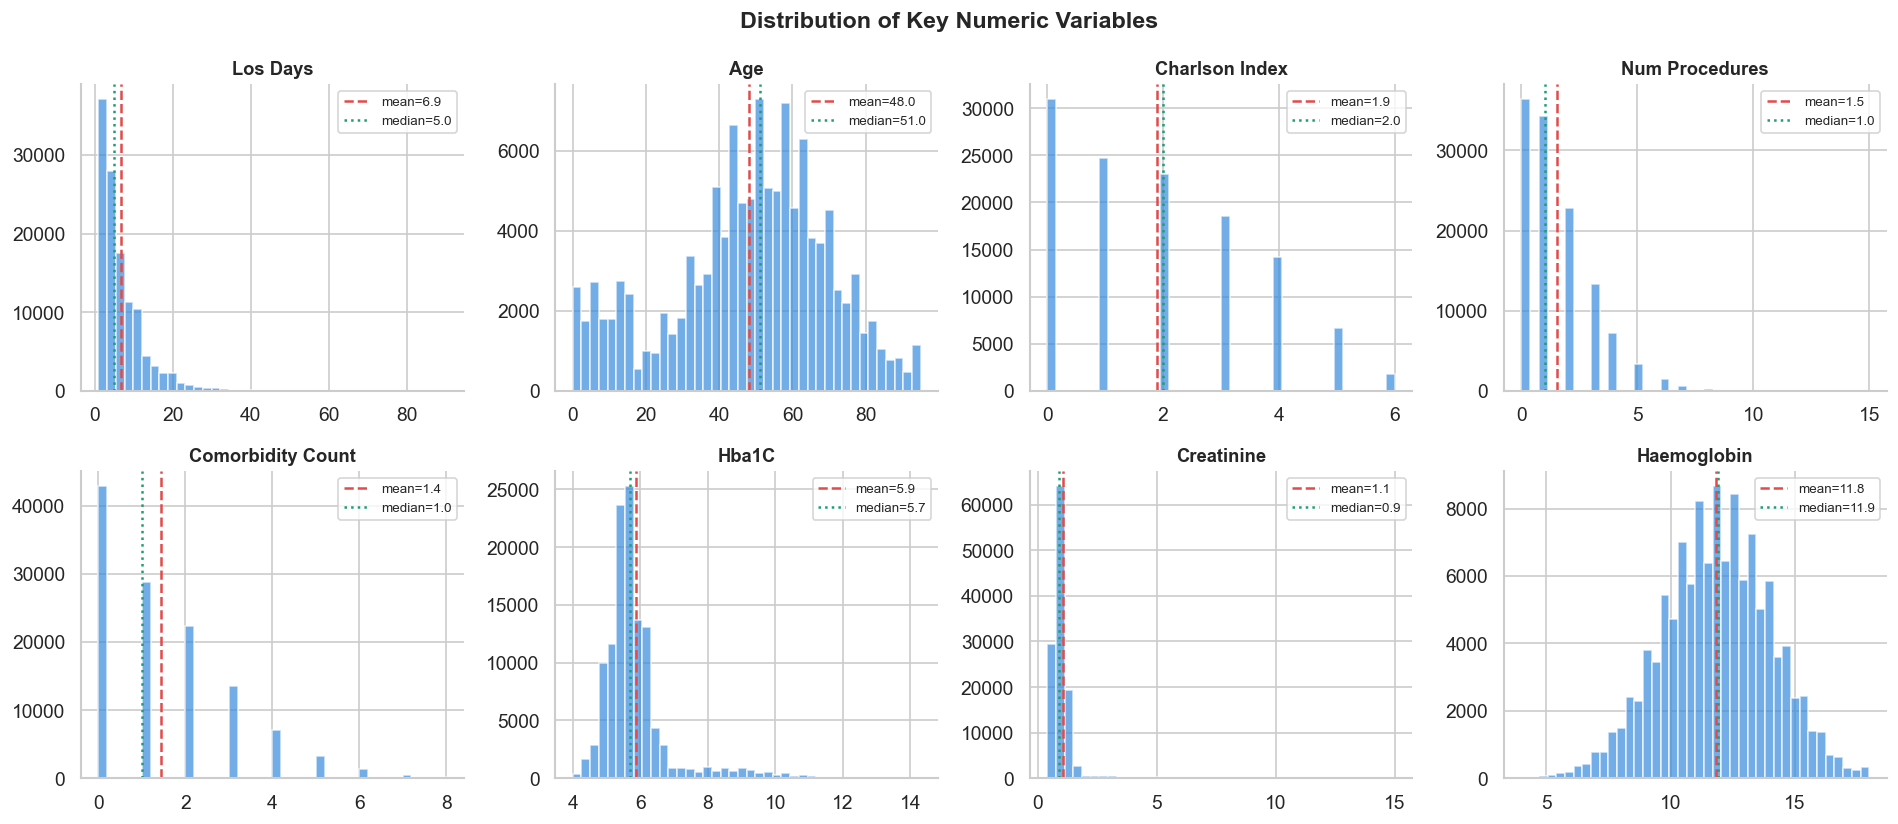

In [45]:
# ── Numeric distributions ─────────────────────────────────────────────────────
num_cols = ['los_days','age','charlson_index','num_procedures',
            'comorbidity_count','hba1c','creatinine','haemoglobin']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#378ADD', alpha=0.7, edgecolor='white')
    axes[i].axvline(data.mean(),   color='#E24B4A', lw=1.5, linestyle='--', label=f'mean={data.mean():.1f}')
    axes[i].axvline(data.median(), color='#1D9E75', lw=1.5, linestyle=':',  label=f'median={data.median():.1f}')
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold', fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

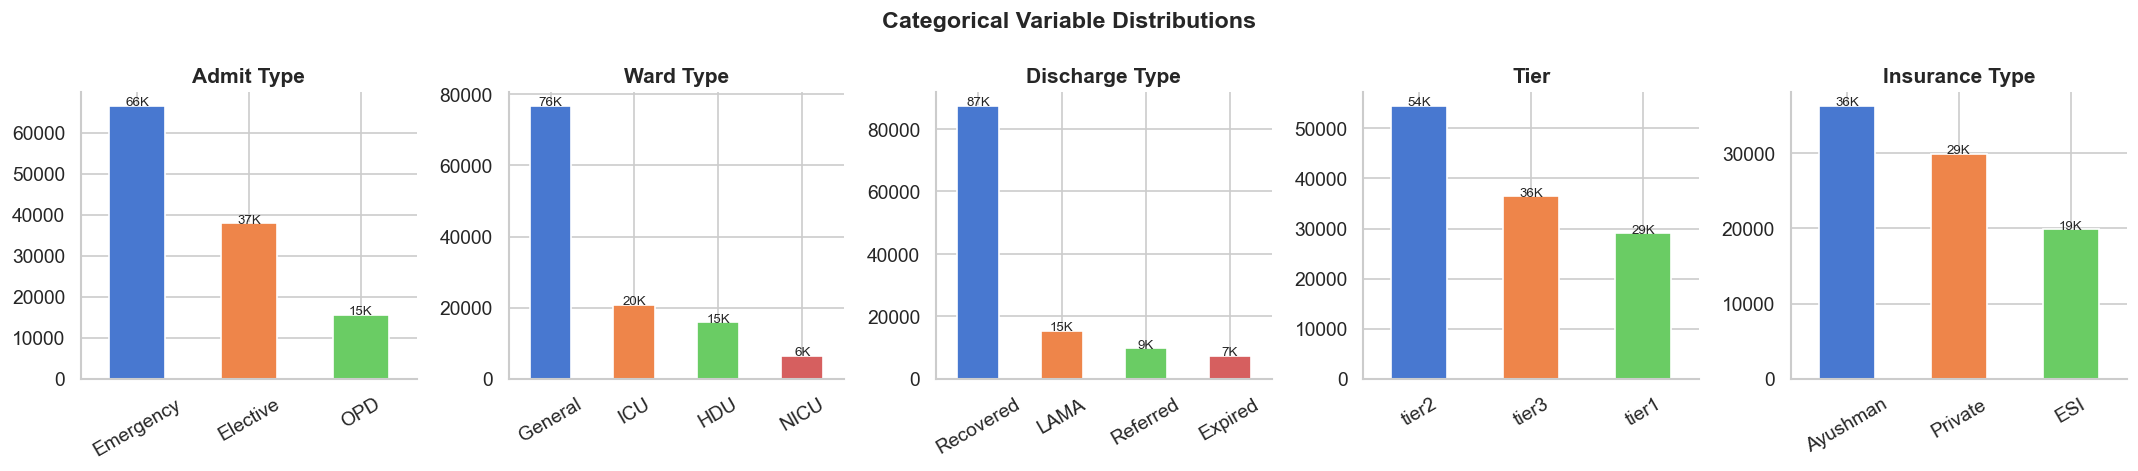

In [46]:
# ── Categorical breakdowns ────────────────────────────────────────────────────
cat_cols = ['admit_type','ward_type','discharge_type','tier','insurance_type']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(cat_cols):
    col_data = df[col].value_counts()
    col_data.plot(kind='bar', ax=axes[i], color=sns.color_palette('muted', len(col_data)))
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                     f'{int(bar.get_height()/1000)}K', ha='center', fontsize=8)

plt.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

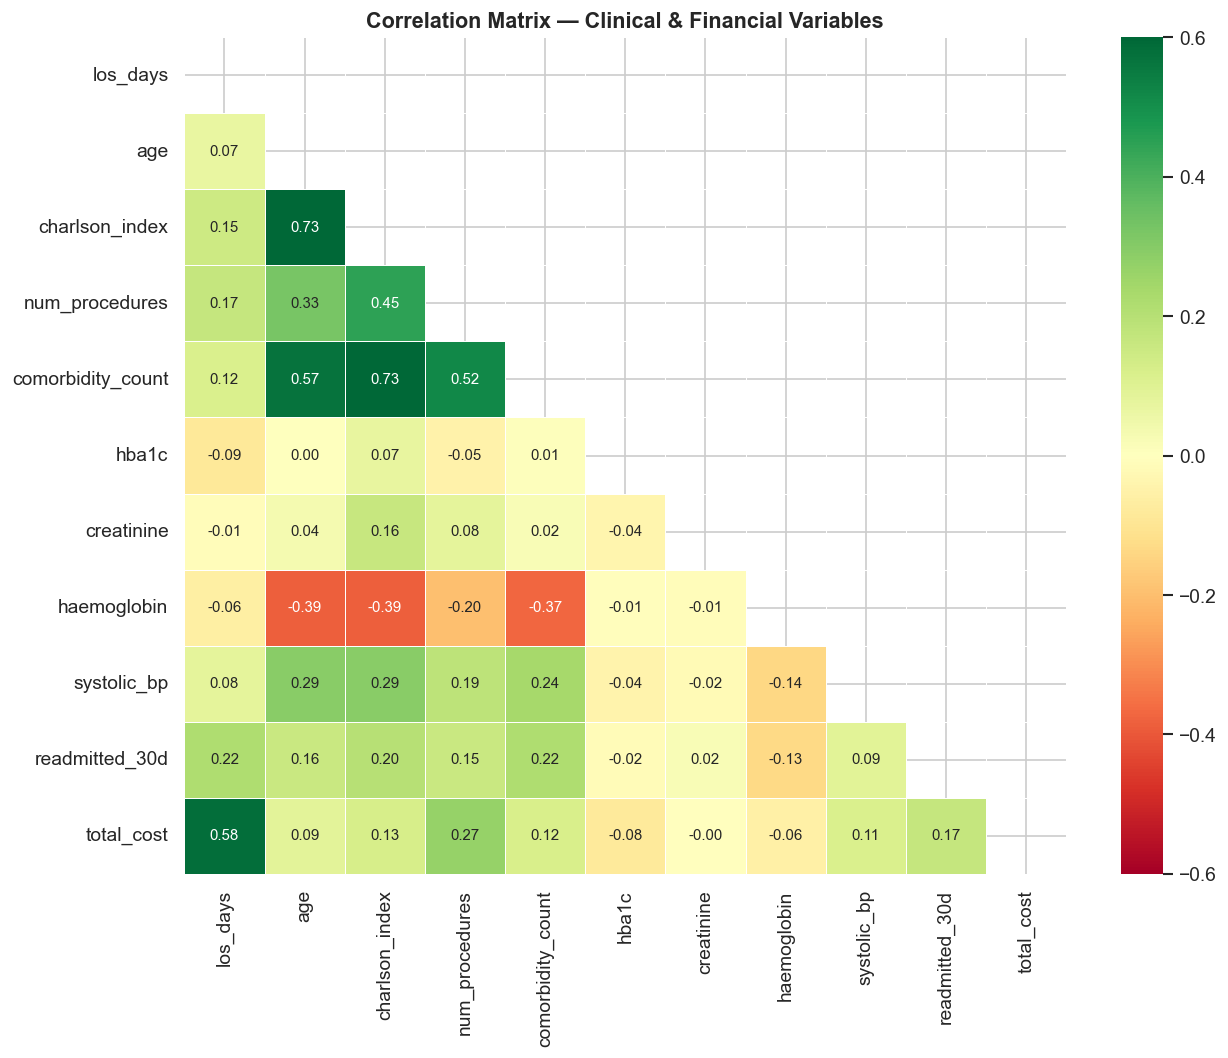

In [47]:
# ── Correlation matrix (clinical variables) ───────────────────────────────────
corr_cols = ['los_days','age','charlson_index','num_procedures','comorbidity_count',
             'hba1c','creatinine','haemoglobin','systolic_bp','readmitted_30d','total_cost']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':9},
            vmin=-0.6, vmax=0.6)
ax.set_title('Correlation Matrix — Clinical & Financial Variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Capacity & Occupancy Analysis <a id='3'></a>

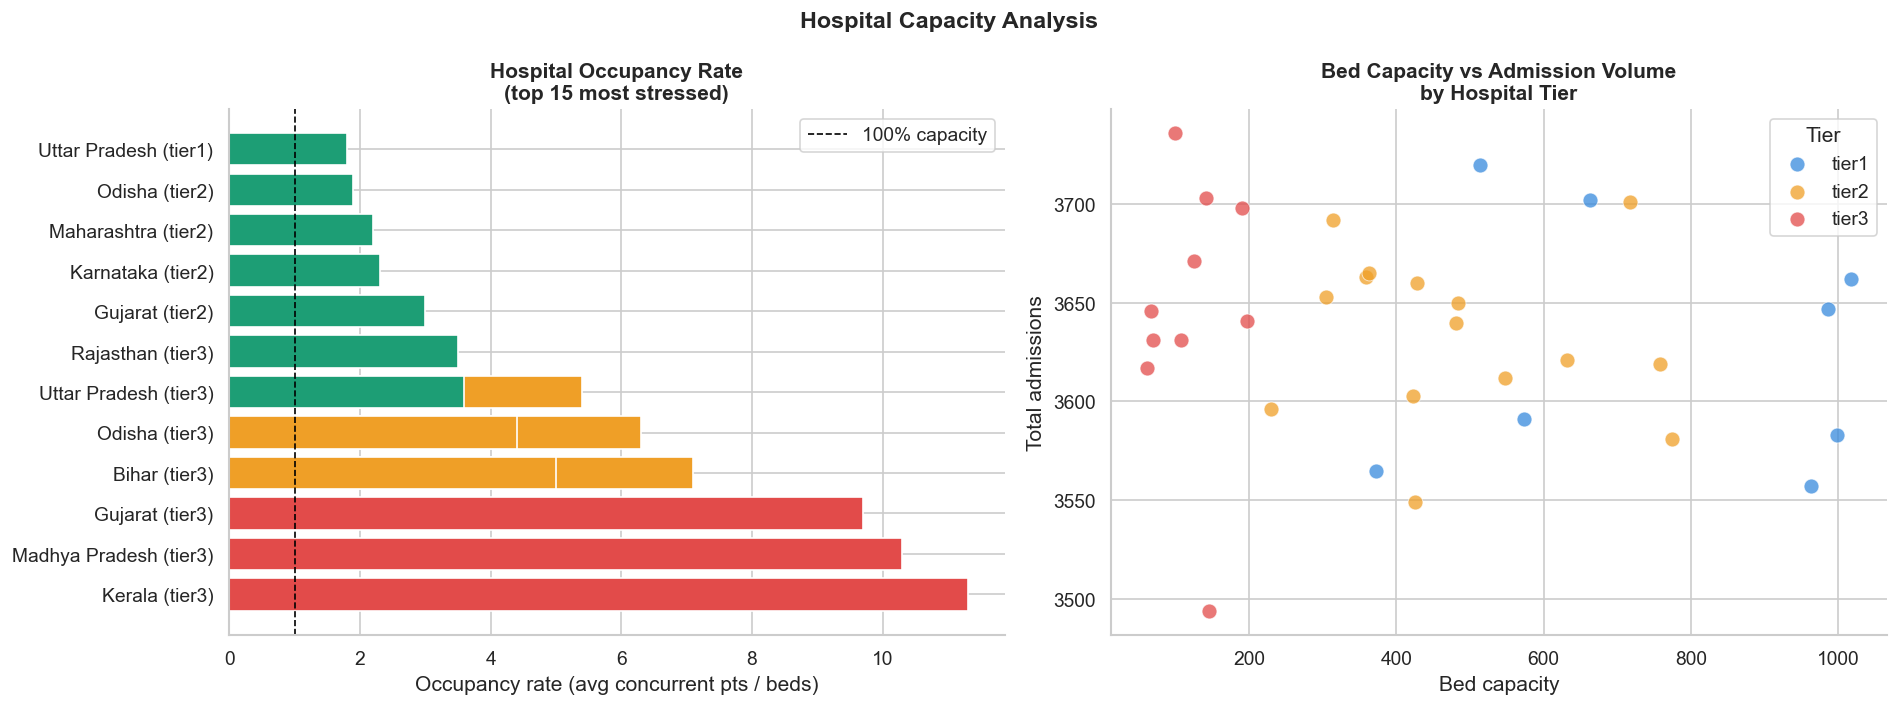


Top 5 overloaded hospitals:
            short_name  beds  n_adm  occupancy_rate  avg_los
        Kerala (tier3)    61   3617            11.3 6.957700
Madhya Pradesh (tier3)    67   3646            10.3 6.885080
       Gujarat (tier3)    70   3631             9.7 6.798678
         Bihar (tier3)    99   3736             7.1 6.851445
        Odisha (tier3)   108   3631             6.3 6.793170


In [48]:
# ── Hospital occupancy rate (proxy: avg concurrent patients / beds) ────────────
obs_days = (df['admit_date'].max() - df['admit_date'].min()).days

hosp_load = (df.groupby('hospital_id')
               .agg(total_los      = ('los_days','sum'),
                    n_adm          = ('admission_id','count'),
                    ra_rate        = ('readmitted_30d','mean'),
                    avg_los        = ('los_days','mean'),
                    avg_procedures = ('num_procedures','mean'))
               .join(hosp.set_index('hospital_id')[['name','beds','tier','state','teaching']]))

hosp_load['avg_concurrent_pts'] = hosp_load['total_los'] / obs_days
hosp_load['occupancy_rate']     = (hosp_load['avg_concurrent_pts'] / hosp_load['beds'] * 100).round(1)
hosp_load['short_name']         = hosp_load['state'] + ' (' + hosp_load['tier'] + ')'

top_occ = hosp_load.sort_values('occupancy_rate', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#E24B4A' if x > 8 else '#EF9F27' if x > 4 else '#1D9E75'
          for x in top_occ['occupancy_rate']]
bars = axes[0].barh(top_occ['short_name'], top_occ['occupancy_rate'], color=colors)
axes[0].axvline(1.0, color='black', linestyle='--', lw=1, label='100% capacity')
axes[0].set_xlabel('Occupancy rate (avg concurrent pts / beds)')
axes[0].set_title('Hospital Occupancy Rate\n(top 15 most stressed)', fontweight='bold')
axes[0].legend()

# Scatter: beds vs admissions
tier_colors = {'tier1':'#378ADD','tier2':'#EF9F27','tier3':'#E24B4A'}
for tier, grp in hosp_load.groupby('tier'):
    axes[1].scatter(grp['beds'], grp['n_adm'], c=tier_colors.get(tier,'gray'),
                    label=tier, alpha=0.75, s=80, edgecolors='white', linewidths=0.5)
axes[1].set_xlabel('Bed capacity')
axes[1].set_ylabel('Total admissions')
axes[1].set_title('Bed Capacity vs Admission Volume\nby Hospital Tier', fontweight='bold')
axes[1].legend(title='Tier')

plt.suptitle('Hospital Capacity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 overloaded hospitals:')
print(top_occ[['short_name','beds','n_adm','occupancy_rate','avg_los']].head(5).to_string(index=False))

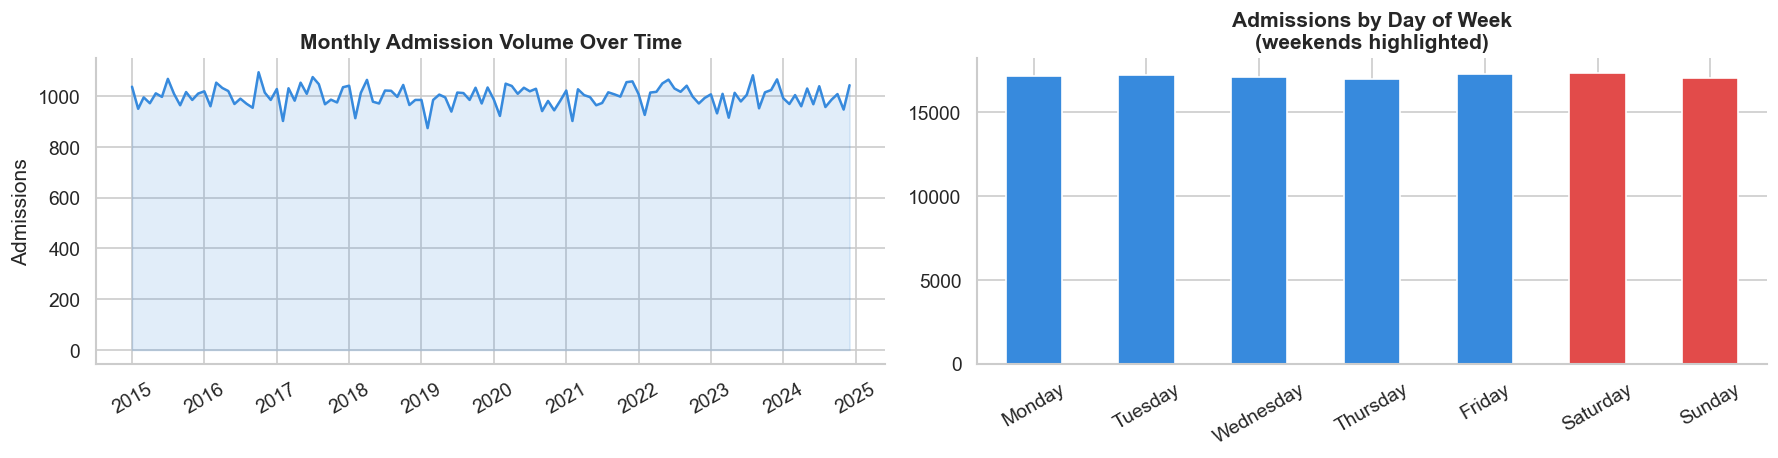

In [49]:
# ── Admission trends over time ─────────────────────────────────────────────────
monthly = df.groupby([df['admit_date'].dt.to_period('M')]).size().reset_index()
monthly.columns = ['period','count']
monthly['date'] = monthly['period'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(monthly['date'], monthly['count'], color='#378ADD', lw=1.5)
axes[0].fill_between(monthly['date'], monthly['count'], alpha=0.15, color='#378ADD')
axes[0].set_title('Monthly Admission Volume Over Time', fontweight='bold')
axes[0].set_ylabel('Admissions')
axes[0].tick_params(axis='x', rotation=30)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('admit_dow_name').size().reindex(dow_order)
colors_dow = ['#E24B4A' if d in ['Saturday','Sunday'] else '#378ADD' for d in dow_order]
dow_counts.plot(kind='bar', ax=axes[1], color=colors_dow)
axes[1].set_title('Admissions by Day of Week\n(weekends highlighted)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Length of Stay (LOS) Deep Dive <a id='4'></a>

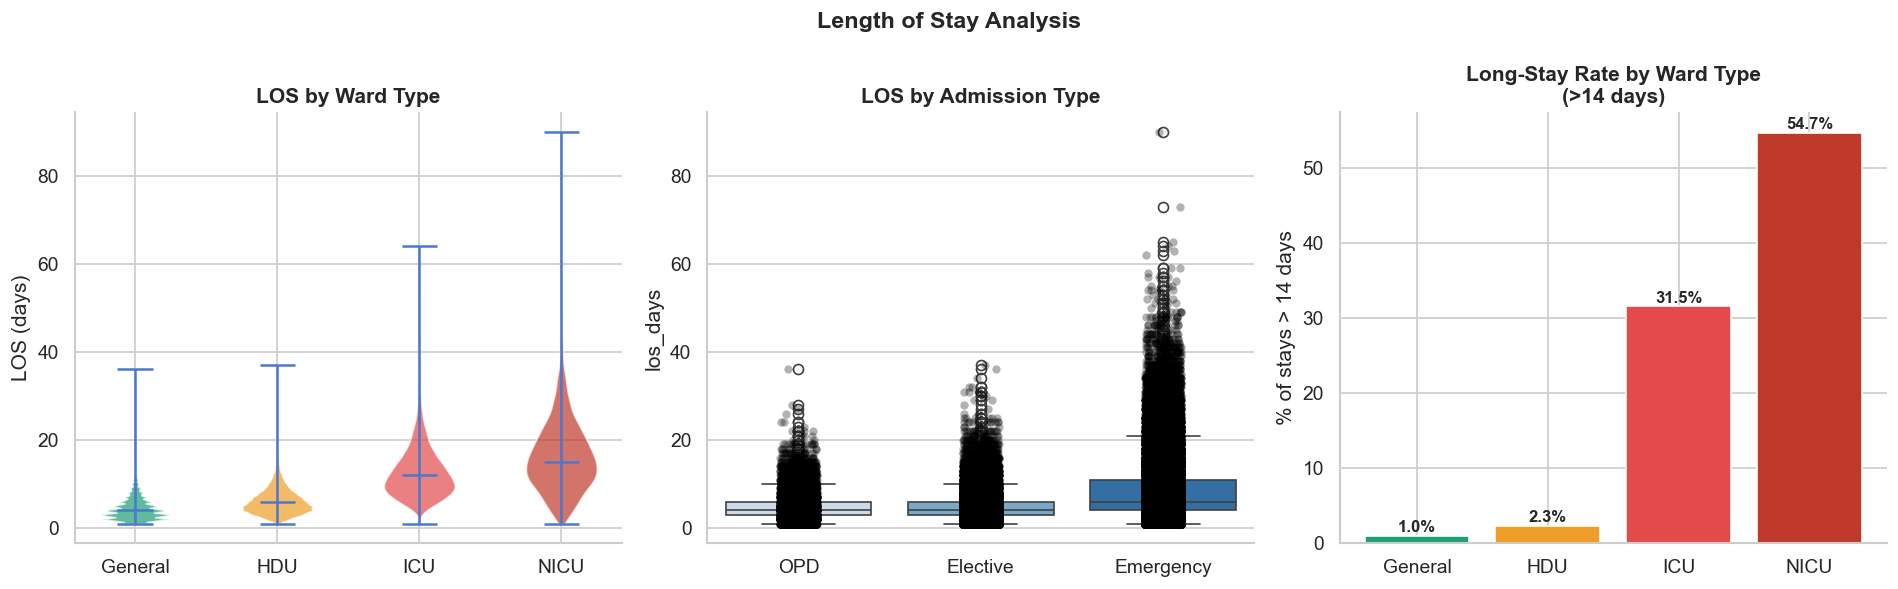

In [50]:
# ── LOS by ward and admit type ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ─────────────────────────────────────────
# 1. Violin plot: LOS by ward type
# ─────────────────────────────────────────
ward_order = ['General','HDU','ICU','NICU']
ward_data  = [df[df['ward_type']==w]['los_days'].dropna() for w in ward_order]

parts = axes[0].violinplot(
    ward_data,
    positions=range(len(ward_order)),
    showmedians=True
)

pal = ['#1D9E75','#EF9F27','#E24B4A','#c0392b']
for pc, col in zip(parts['bodies'], pal):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)

axes[0].set_xticks(range(len(ward_order)))
axes[0].set_xticklabels(ward_order)
axes[0].set_ylabel('LOS (days)')
axes[0].set_title('LOS by Ward Type', fontweight='bold')

# ─────────────────────────────────────────
# 2. FIXED Box plot: LOS by admit type
# ─────────────────────────────────────────
admit_order = ['OPD','Elective','Emergency']
df_plot = df[df['admit_type'].isin(admit_order)]

sns.boxplot(
    x='admit_type',
    y='los_days',
    data=df_plot,
    order=admit_order,
    ax=axes[1],
    palette='Blues'
)

# OPTIONAL (🔥 adds research-level quality)
sns.stripplot(
    x='admit_type',
    y='los_days',
    data=df_plot,
    order=admit_order,
    color='black',
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title('LOS by Admission Type', fontweight='bold')
axes[1].set_xlabel('')

# ─────────────────────────────────────────
# 3. Long-stay (>14d) rates by ward
# ─────────────────────────────────────────
long_stay = df.groupby('ward_type').apply(
    lambda x: (x['los_days'] > 14).mean() * 100
).reindex(ward_order)

bars = axes[2].bar(long_stay.index, long_stay.values, color=pal)

for bar, val in zip(bars, long_stay.values):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

axes[2].set_ylabel('% of stays > 14 days')
axes[2].set_title('Long-Stay Rate by Ward Type\n(>14 days)', fontweight='bold')

# ─────────────────────────────────────────
# Final layout
# ─────────────────────────────────────────
plt.suptitle('Length of Stay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

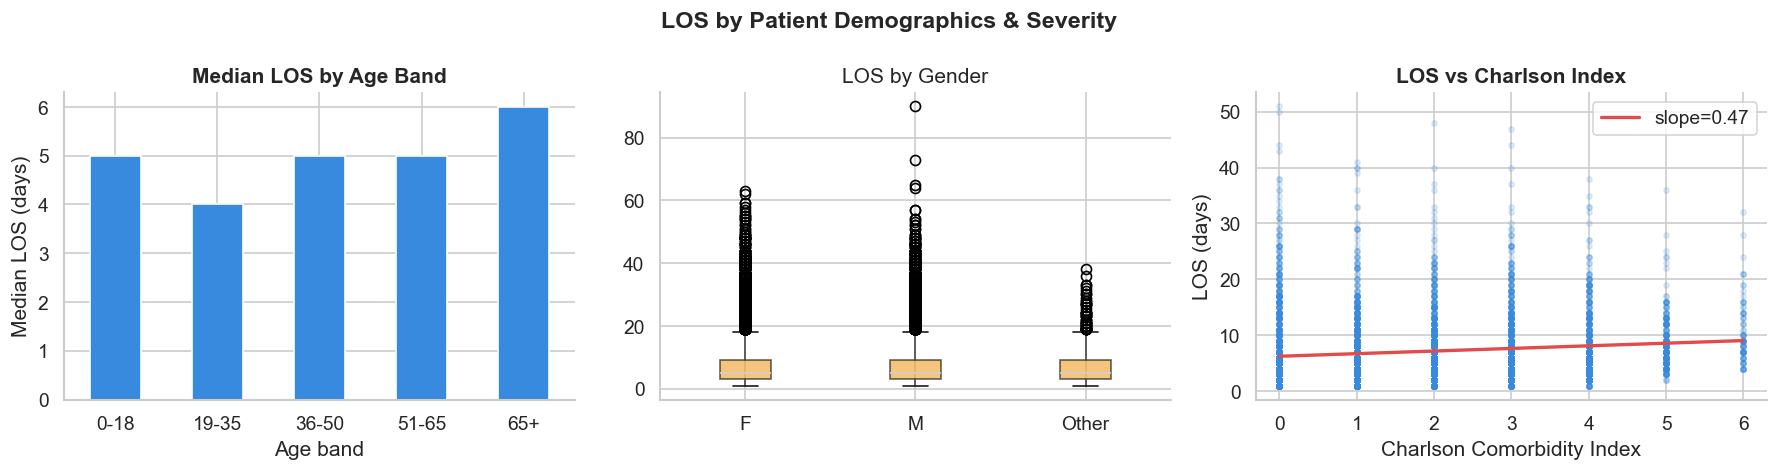

In [51]:
# ── LOS by patient demographics ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age band
age_los = df.groupby('age_band')['los_days'].median()
age_los.plot(kind='bar', ax=axes[0], color='#378ADD', edgecolor='white')
axes[0].set_title('Median LOS by Age Band', fontweight='bold')
axes[0].set_xlabel('Age band'); axes[0].set_ylabel('Median LOS (days)')
axes[0].tick_params(axis='x', rotation=0)

# Gender
df.boxplot(column='los_days', by='gender', ax=axes[1],
           patch_artist=True, boxprops={'facecolor':'#EF9F27','alpha':0.6})
axes[1].set_title('LOS by Gender', fontweight='bold')
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('LOS by Gender')

# Charlson index vs LOS (scatter with regression)
sample = df[['charlson_index','los_days']].dropna().sample(min(5000, len(df)), random_state=42)
axes[2].scatter(sample['charlson_index'], sample['los_days'],
                alpha=0.15, s=10, color='#378ADD')
m, b = np.polyfit(sample['charlson_index'], sample['los_days'], 1)
x_line = np.linspace(sample['charlson_index'].min(), sample['charlson_index'].max(), 100)
axes[2].plot(x_line, m*x_line+b, color='#E24B4A', lw=2, label=f'slope={m:.2f}')
axes[2].set_xlabel('Charlson Comorbidity Index'); axes[2].set_ylabel('LOS (days)')
axes[2].set_title('LOS vs Charlson Index', fontweight='bold')
axes[2].legend()

plt.suptitle('LOS by Patient Demographics & Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Readmission Analysis <a id='5'></a>

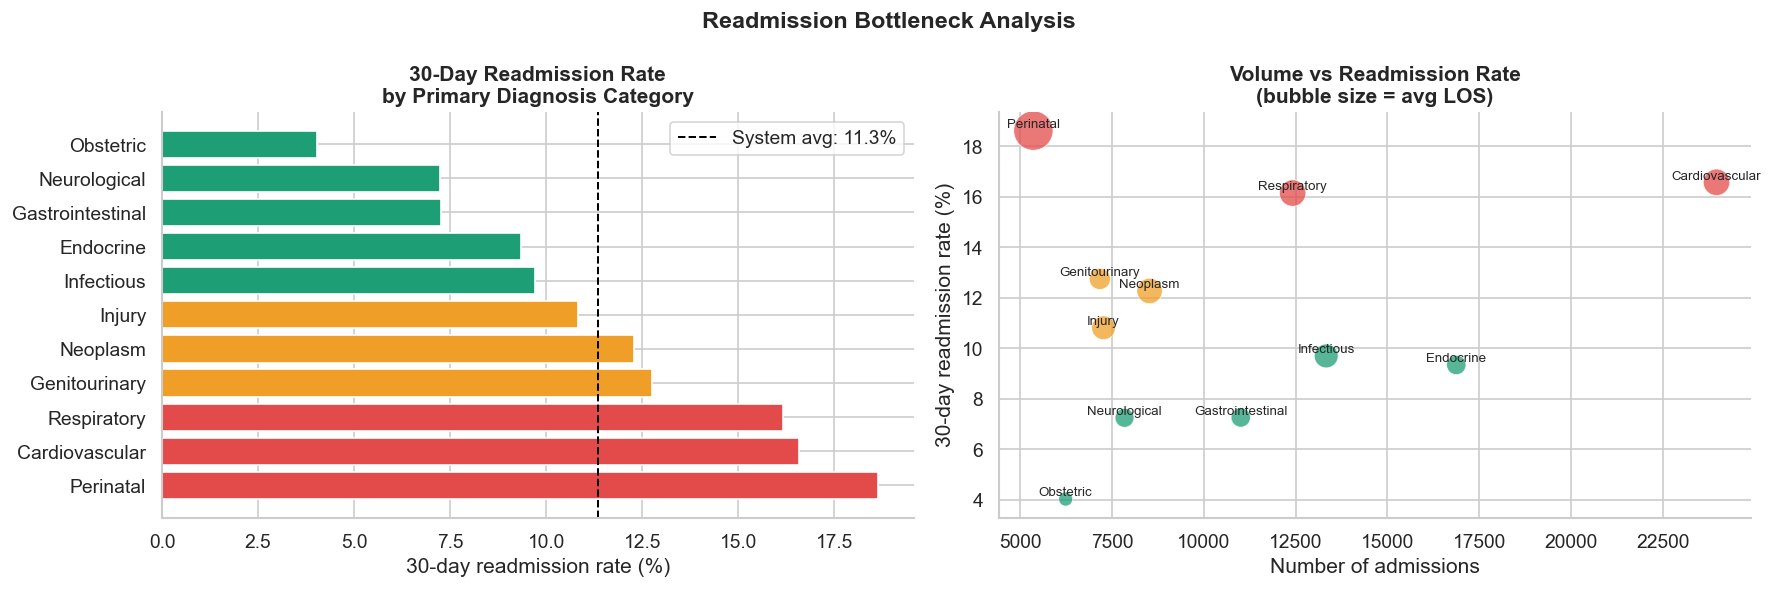

In [52]:
# ── Readmission by diagnosis category ─────────────────────────────────────────
prim_diag = diag[diag['diag_rank']==1].merge(
    df[['admission_id','readmitted_30d','readmitted_7d','los_days']], on='admission_id')

ra_by_diag = (prim_diag.groupby('diag_category')
                        .agg(ra30 = ('readmitted_30d','mean'),
                             ra7  = ('readmitted_7d','mean'),
                             n    = ('readmitted_30d','count'),
                             avg_los = ('los_days','mean'))
                        .sort_values('ra30', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_ra = ['#E24B4A' if v>0.15 else '#EF9F27' if v>0.10 else '#1D9E75'
             for v in ra_by_diag['ra30']]
bars = axes[0].barh(ra_by_diag.index, ra_by_diag['ra30']*100, color=colors_ra)
axes[0].axvline(ra_by_diag['ra30'].mean()*100, color='black', lw=1.2,
                linestyle='--', label=f"System avg: {ra_by_diag['ra30'].mean()*100:.1f}%")
axes[0].set_xlabel('30-day readmission rate (%)')
axes[0].set_title('30-Day Readmission Rate\nby Primary Diagnosis Category', fontweight='bold')
axes[0].legend()

# Bubble chart: volume vs readmission rate
scatter = axes[1].scatter(ra_by_diag['n'], ra_by_diag['ra30']*100,
                          s=ra_by_diag['avg_los']*30,
                          c=colors_ra, alpha=0.75, edgecolors='white', linewidths=0.5)
for idx, row in ra_by_diag.iterrows():
    axes[1].annotate(idx, (row['n'], row['ra30']*100),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel('Number of admissions')
axes[1].set_ylabel('30-day readmission rate (%)')
axes[1].set_title('Volume vs Readmission Rate\n(bubble size = avg LOS)', fontweight='bold')

plt.suptitle('Readmission Bottleneck Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

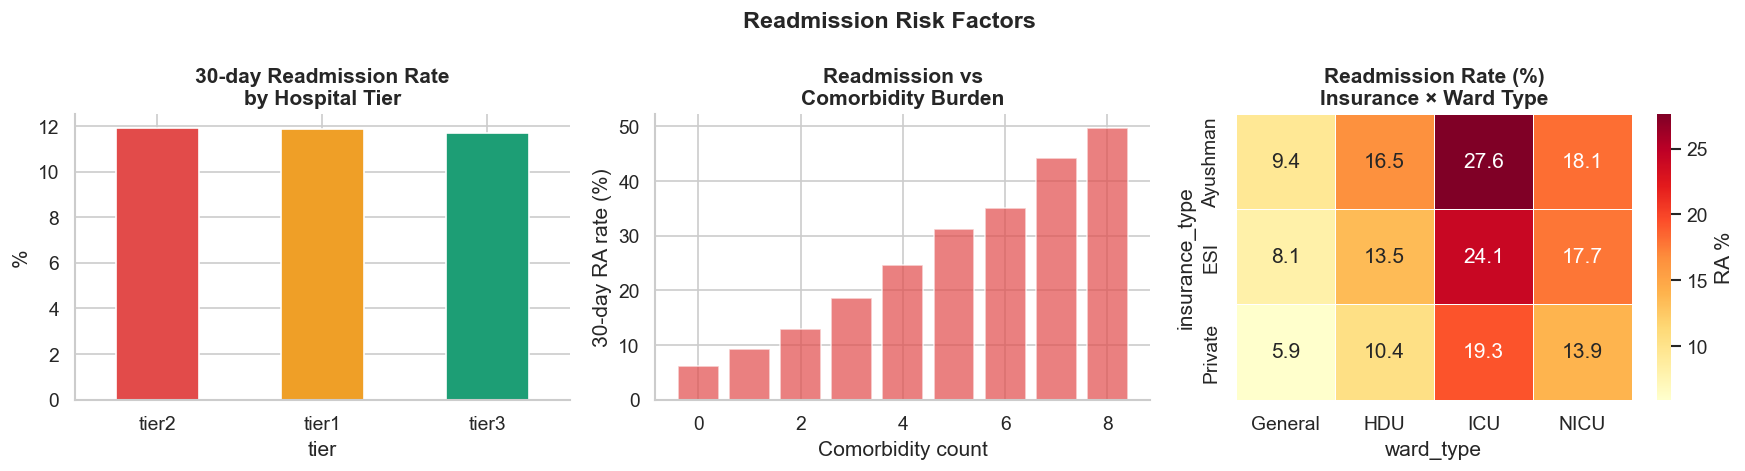

In [53]:
# ── Readmission by hospital tier & risk factors ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tier comparison
tier_ra = df.groupby('tier')['readmitted_30d'].mean().sort_values(ascending=False)
tier_ra.mul(100).plot(kind='bar', ax=axes[0],
                      color=['#E24B4A','#EF9F27','#1D9E75'][:len(tier_ra)])
axes[0].set_title('30-day Readmission Rate\nby Hospital Tier', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].tick_params(axis='x', rotation=0)

# Comorbidity count vs readmission
cc_ra = df.groupby('comorbidity_count')['readmitted_30d'].mean()
axes[1].bar(cc_ra.index, cc_ra.values*100, color='#E24B4A', alpha=0.7)
axes[1].set_xlabel('Comorbidity count'); axes[1].set_ylabel('30-day RA rate (%)')
axes[1].set_title('Readmission vs\nComorbidity Burden', fontweight='bold')

# Insurance type readmission heatmap
ins_ra = df.groupby(['insurance_type','ward_type'])['readmitted_30d'].mean().unstack()
sns.heatmap(ins_ra.mul(100), annot=True, fmt='.1f', ax=axes[2],
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label':'RA %'})
axes[2].set_title('Readmission Rate (%)\nInsurance × Ward Type', fontweight='bold')

plt.suptitle('Readmission Risk Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Financial & Billing Analysis <a id='6'></a>

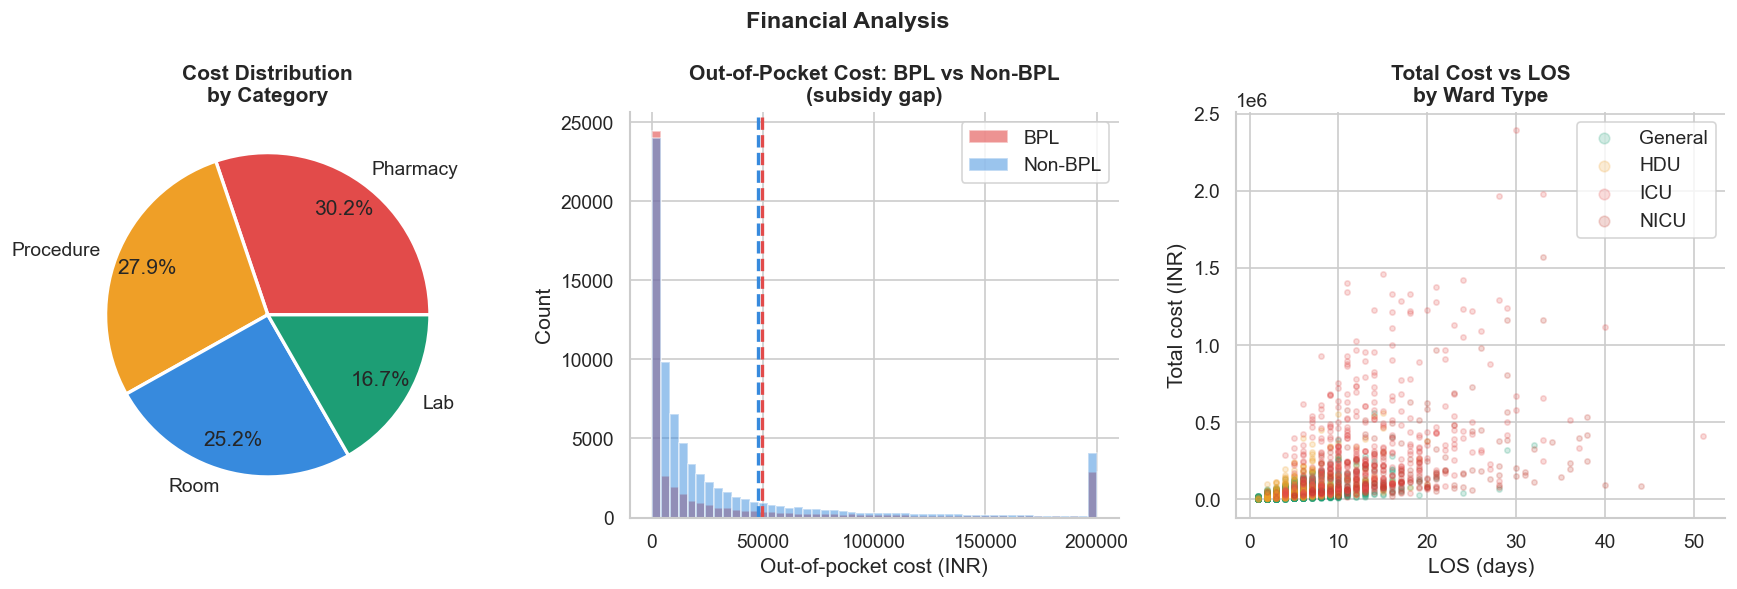


BPL avg OOP    : ₹49,341
Non-BPL avg OOP: ₹47,500
BPL subsidy coverage: 48.4%


In [54]:
# ── Cost breakdown & distributions ────────────────────────────────────────────
cost_cat = bill.groupby('cost_category')['total_cost_inr'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Donut chart: cost categories
wedges, texts, autotexts = axes[0].pie(
    cost_cat.values,
    labels=cost_cat.index,
    autopct='%1.1f%%',
    colors=['#E24B4A','#EF9F27','#378ADD','#1D9E75'],
    pctdistance=0.8,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[0].set_title('Cost Distribution\nby Category', fontweight='bold')

# OOP distribution: BPL vs non-BPL
bpl_oop     = df[df['bpl_card']==True]['oop_cost'].dropna()
nonbpl_oop  = df[df['bpl_card']==False]['oop_cost'].dropna()
axes[1].hist(bpl_oop.clip(0,200000),    bins=50, alpha=0.6, color='#E24B4A', label='BPL')
axes[1].hist(nonbpl_oop.clip(0,200000), bins=50, alpha=0.5, color='#378ADD', label='Non-BPL')
axes[1].axvline(bpl_oop.mean(),    color='#E24B4A', lw=2, linestyle='--')
axes[1].axvline(nonbpl_oop.mean(), color='#378ADD', lw=2, linestyle='--')
axes[1].set_xlabel('Out-of-pocket cost (INR)'); axes[1].set_ylabel('Count')
axes[1].set_title('Out-of-Pocket Cost: BPL vs Non-BPL\n(subsidy gap)', fontweight='bold')
axes[1].legend()

# Cost vs LOS scatter
sample2 = df[['los_days','total_cost','ward_type']].dropna().sample(3000, random_state=42)
for ward, grp in sample2.groupby('ward_type'):
    axes[2].scatter(grp['los_days'], grp['total_cost'],
                    alpha=0.2, s=10, label=ward, color=PALETTE.get(ward,'gray'))
axes[2].set_xlabel('LOS (days)'); axes[2].set_ylabel('Total cost (INR)')
axes[2].set_title('Total Cost vs LOS\nby Ward Type', fontweight='bold')
axes[2].legend(markerscale=2)

plt.suptitle('Financial Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBPL avg OOP    : ₹{bpl_oop.mean():,.0f}")
print(f"Non-BPL avg OOP: ₹{nonbpl_oop.mean():,.0f}")
print(f"BPL subsidy coverage: {df[df['bpl_card']]['subsidy'].sum()/df[df['bpl_card']]['total_cost'].sum()*100:.1f}%")

## 7. Statistical Hypothesis Testing <a id='7'></a>

In [55]:
# ── Test 1: Kruskal-Wallis — LOS differs across ward types ────────────────────
groups_ward = [df[df['ward_type']==w]['los_days'].dropna() for w in ['General','HDU','ICU','NICU']]
h_stat, p_kw = kruskal(*groups_ward)
print('=' * 60)
print('TEST 1: Kruskal-Wallis — LOS across ward types')
print(f'H-statistic: {h_stat:.2f}   p-value: {p_kw:.2e}')
print(f'Result: {"SIGNIFICANT" if p_kw < 0.05 else "NOT significant"} (α=0.05)')

# Pairwise Mann-Whitney
print('\nPairwise Mann-Whitney U (Bonferroni α=0.0083):')
wards = ['General','HDU','ICU','NICU']
for i in range(len(wards)):
    for j in range(i+1, len(wards)):
        g1 = df[df['ward_type']==wards[i]]['los_days'].dropna()
        g2 = df[df['ward_type']==wards[j]]['los_days'].dropna()
        u, p = mannwhitneyu(g1, g2)
        sig = '✓ sig' if p < 0.0083 else '✗ ns'
        print(f'  {wards[i]} vs {wards[j]}: p={p:.2e}  {sig}')

TEST 1: Kruskal-Wallis — LOS across ward types
H-statistic: 49408.58   p-value: 0.00e+00
Result: SIGNIFICANT (α=0.05)

Pairwise Mann-Whitney U (Bonferroni α=0.0083):
  General vs HDU: p=0.00e+00  ✓ sig
  General vs ICU: p=0.00e+00  ✓ sig
  General vs NICU: p=0.00e+00  ✓ sig
  HDU vs ICU: p=0.00e+00  ✓ sig
  HDU vs NICU: p=0.00e+00  ✓ sig
  ICU vs NICU: p=4.61e-253  ✓ sig


In [56]:
# ── Test 2: Chi-squared — readmission associated with admit type? ──────────────
ct = pd.crosstab(df['admit_type'], df['readmitted_30d'])
chi2, p_chi2, dof, expected = chi2_contingency(ct)
print('=' * 60)
print('TEST 2: Chi-squared — readmission × admit type')
print(f'χ² = {chi2:.2f}   df={dof}   p={p_chi2:.2e}')
print(f'Result: {"SIGNIFICANT" if p_chi2 < 0.05 else "NOT significant"}')

# ── Test 3: Mann-Whitney — BPL vs non-BPL OOP ─────────────────────────────────
bpl_oop    = df[df['bpl_card']==True]['oop_cost'].dropna()
nonbpl_oop = df[df['bpl_card']==False]['oop_cost'].dropna()
u3, p_mw3 = mannwhitneyu(bpl_oop, nonbpl_oop)
print('\n' + '=' * 60)
print('TEST 3: Mann-Whitney — OOP cost: BPL vs non-BPL')
print(f'U = {u3:.0f}   p = {p_mw3:.2e}')
print(f'BPL median OOP:     ₹{bpl_oop.median():,.0f}')
print(f'Non-BPL median OOP: ₹{nonbpl_oop.median():,.0f}')
print(f'Result: {"SIGNIFICANT" if p_mw3 < 0.05 else "NOT significant"}')

# ── Test 4: Kruskal-Wallis — LOS across tiers ─────────────────────────────────
groups_tier = [df[df['tier']==t]['los_days'].dropna() for t in ['tier1','tier2','tier3']]
h4, p_kw4 = kruskal(*groups_tier)
print('\n' + '=' * 60)
print('TEST 4: Kruskal-Wallis — LOS across hospital tiers')
print(f'H = {h4:.2f}   p = {p_kw4:.2e}')
for t in ['tier1','tier2','tier3']:
    m = df[df['tier']==t]['los_days'].median()
    print(f'  {t} median LOS: {m:.1f} days')

TEST 2: Chi-squared — readmission × admit type
χ² = 1267.90   df=2   p=4.79e-276
Result: SIGNIFICANT

TEST 3: Mann-Whitney — OOP cost: BPL vs non-BPL
U = 1217087589   p = 0.00e+00
BPL median OOP:     ₹1,084
Non-BPL median OOP: ₹10,356
Result: SIGNIFICANT

TEST 4: Kruskal-Wallis — LOS across hospital tiers
H = 0.90   p = 6.37e-01
  tier1 median LOS: 5.0 days
  tier2 median LOS: 5.0 days
  tier3 median LOS: 5.0 days


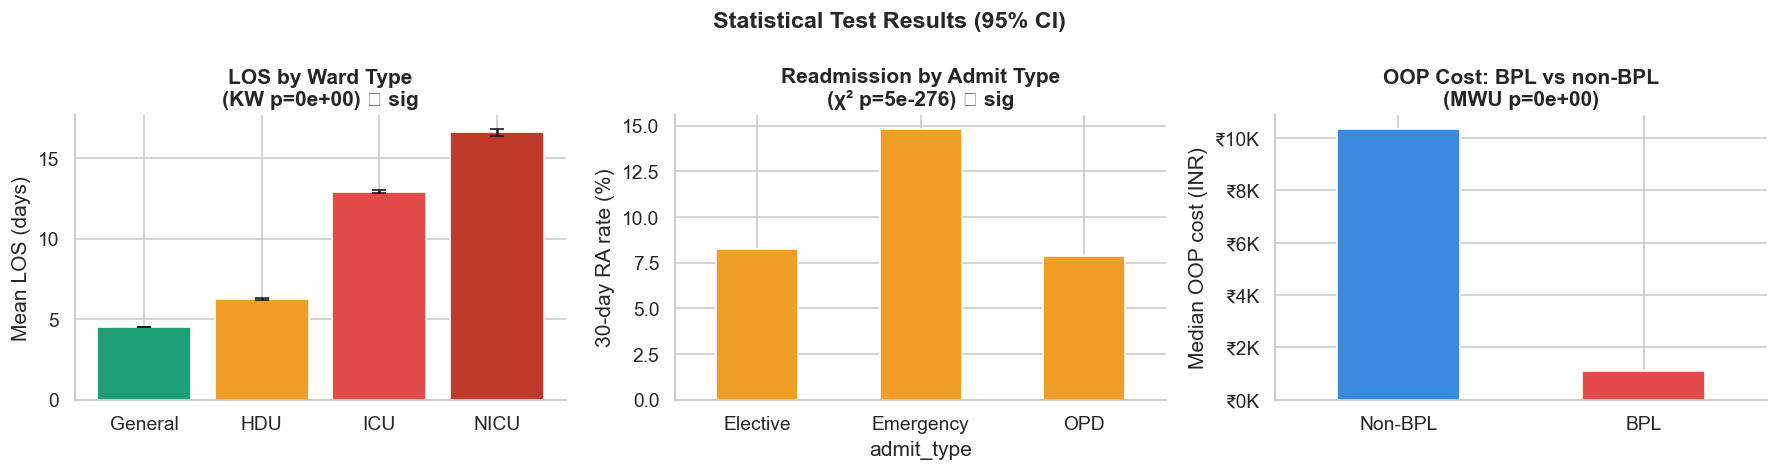

In [57]:
# ── Visual summary of statistical tests ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# LOS by ward (KW result visual)
los_means = df.groupby('ward_type')['los_days'].agg(['mean','sem']).reindex(ward_order)
axes[0].bar(los_means.index, los_means['mean'],
            yerr=los_means['sem']*1.96, capsize=4,
            color=['#1D9E75','#EF9F27','#E24B4A','#c0392b'],
            error_kw={'elinewidth':1.5})
axes[0].set_ylabel('Mean LOS (days)'); axes[0].set_xlabel('')
axes[0].set_title(f'LOS by Ward Type\n(KW p={p_kw:.0e}) ✓ sig', fontweight='bold')

# Readmission by admit type
ra_admit = df.groupby('admit_type')['readmitted_30d'].mean() * 100
ra_admit.plot(kind='bar', ax=axes[1], color='#EF9F27', edgecolor='white')
axes[1].set_ylabel('30-day RA rate (%)')
axes[1].set_title(f'Readmission by Admit Type\n(χ² p={p_chi2:.0e}) ✓ sig', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# OOP: BPL vs non-BPL
oop_grp = df.groupby('bpl_card')['oop_cost'].agg(['median','mean'])
oop_grp.index = ['Non-BPL','BPL']
oop_grp['median'].plot(kind='bar', ax=axes[2], color=['#378ADD','#E24B4A'])
axes[2].set_ylabel('Median OOP cost (INR)')
axes[2].set_title(f'OOP Cost: BPL vs non-BPL\n(MWU p={p_mw3:.0e})', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.suptitle('Statistical Test Results (95% CI)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Machine Learning — LOS Prediction <a id='8'></a>

In [58]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

# ── Prepare features ──────────────────────────────────────────────────────────
feat_cols = ['admit_type','ward_type','tier','charlson_index','num_procedures',
             'age','comorbidity_count','prev_admissions','hba1c',
             'creatinine','haemoglobin','systolic_bp']
target    = 'los_days'

ml = df[feat_cols + [target]].dropna().copy()
for c in ['admit_type','ward_type','tier']:
    ml[c] = LabelEncoder().fit_transform(ml[c].astype(str))

X = ml[feat_cols]; y = ml[target]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Train 3 models ────────────────────────────────────────────────────────────
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                    learning_rate=0.05, random_state=42),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, max_depth=8,
                                               n_jobs=-1, random_state=42),
    'Ridge Regression' : Ridge(alpha=1.0)
}

results = {}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    results[name] = {
        'MAE' : mean_absolute_error(y_te, preds),
        'RMSE': np.sqrt(mean_squared_error(y_te, preds)),
        'R2'  : r2_score(y_te, preds),
        'preds': preds
    }
    print(f'{name:25s}  MAE={results[name]["MAE"]:.2f}d  RMSE={results[name]["RMSE"]:.2f}d  R²={results[name]["R2"]:.3f}')

Gradient Boosting          MAE=2.66d  RMSE=3.90d  R²=0.532
Random Forest              MAE=2.66d  RMSE=3.90d  R²=0.532
Ridge Regression           MAE=2.86d  RMSE=4.16d  R²=0.465


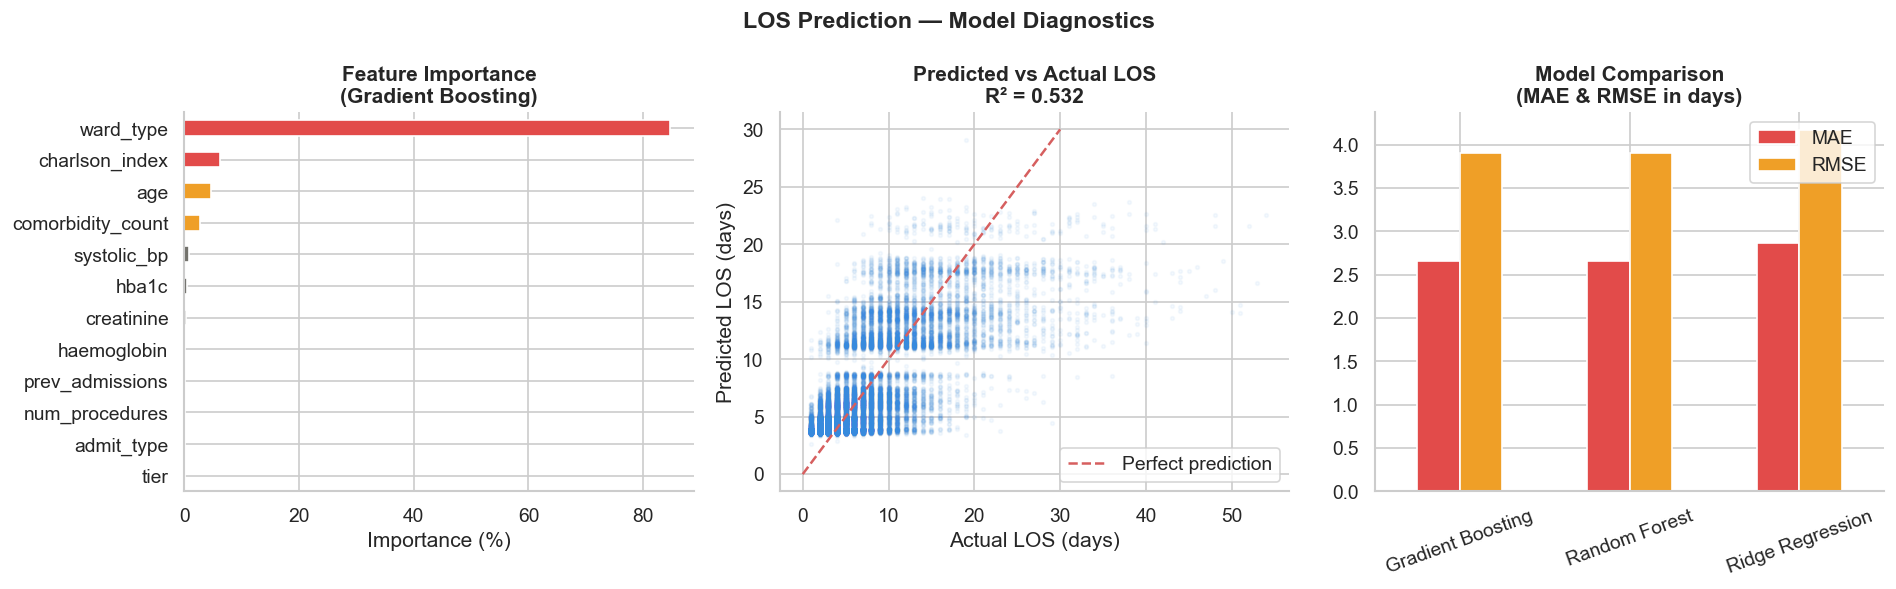

In [59]:
# ── LOS model diagnostics & feature importance ────────────────────────────────
best_model = models['Gradient Boosting']
fi = pd.Series(best_model.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Feature importance
colors_fi = ['#E24B4A' if v > 0.05 else '#EF9F27' if v > 0.01 else '#73726c'
             for v in fi.values]
fi.mul(100).plot(kind='barh', ax=axes[0], color=colors_fi)
axes[0].set_xlabel('Importance (%)')
axes[0].set_title('Feature Importance\n(Gradient Boosting)', fontweight='bold')

# Predicted vs actual
preds_gb = results['Gradient Boosting']['preds']
axes[1].scatter(y_te, preds_gb, alpha=0.05, s=5, color='#378ADD')
axes[1].plot([0, 30], [0, 30], 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual LOS (days)'); axes[1].set_ylabel('Predicted LOS (days)')
axes[1].set_title(f'Predicted vs Actual LOS\nR² = {results["Gradient Boosting"]["R2"]:.3f}',
                  fontweight='bold')
axes[1].legend()

# Model comparison
metrics_df = pd.DataFrame({k: {'MAE':v['MAE'],'RMSE':v['RMSE'],'R2':v['R2']}
                            for k,v in results.items()}).T
metrics_df[['MAE','RMSE']].plot(kind='bar', ax=axes[2],
                                 color=['#E24B4A','#EF9F27'], edgecolor='white')
axes[2].set_title('Model Comparison\n(MAE & RMSE in days)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('LOS Prediction — Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Machine Learning — Readmission Risk Score <a id='9'></a>

In [60]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler

# ── Features ──────────────────────────────────────────────────────────────────
feat2 = ['admit_type','ward_type','tier','charlson_index','num_procedures',
         'age','comorbidity_count','prev_admissions','los_days',
         'total_cost','hba1c','creatinine']

ml2 = df[feat2 + ['readmitted_30d']].dropna().copy()
for c in ['admit_type','ward_type','tier']:
    ml2[c] = LabelEncoder().fit_transform(ml2[c].astype(str))

X2 = ml2[feat2]; y2 = ml2['readmitted_30d']
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Scale for logistic regression
scaler = StandardScaler()
X_tr2_sc = scaler.fit_transform(X_tr2)
X_te2_sc = scaler.transform(X_te2)

cls_models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

cls_results = {}
for name, model in cls_models.items():
    X_tr_use = X_tr2_sc if name == 'Logistic Regression' else X_tr2
    X_te_use = X_te2_sc if name == 'Logistic Regression' else X_te2
    model.fit(X_tr_use, y_tr2)
    proba = model.predict_proba(X_te_use)[:,1]
    auc   = roc_auc_score(y_te2, proba)
    cls_results[name] = {'proba': proba, 'auc': auc, 'model': model}
    print(f'{name:25s}  AUC = {auc:.3f}')

Random Forest              AUC = 0.736
Gradient Boosting          AUC = 0.737
Logistic Regression        AUC = 0.735


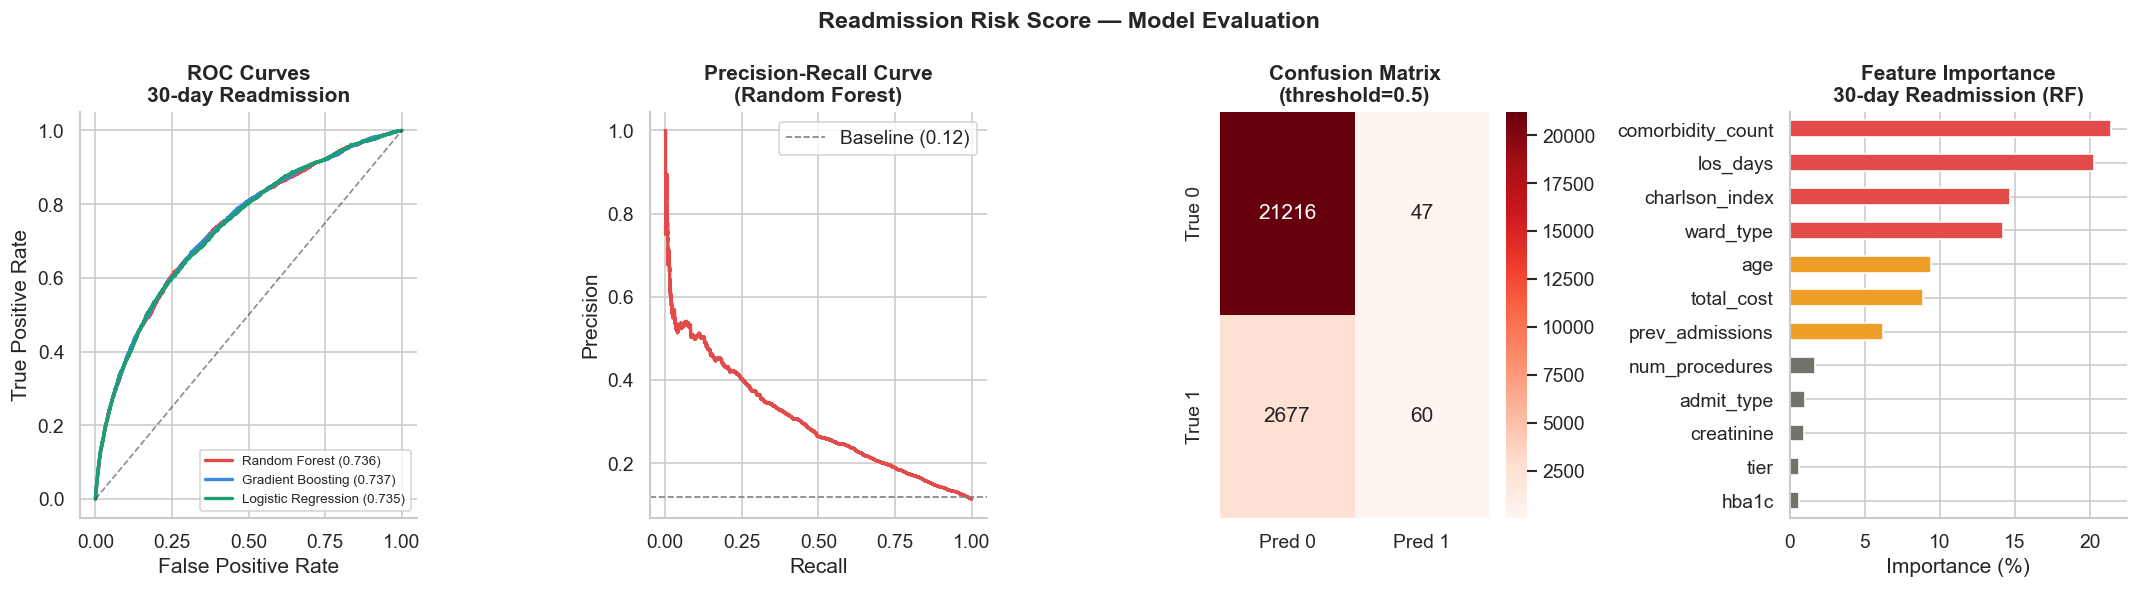


Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     21263
           1       0.56      0.02      0.04      2737

    accuracy                           0.89     24000
   macro avg       0.72      0.51      0.49     24000
weighted avg       0.85      0.89      0.84     24000



In [61]:
# ── ROC, PR curves, confusion matrix, feature importance ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# ROC curves
colors_roc = ['#E24B4A','#378ADD','#1D9E75']
for (name, res), col in zip(cls_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_te2, res['proba'])
    axes[0].plot(fpr, tpr, lw=2, color=col, label=f"{name} ({res['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves\n30-day Readmission', fontweight='bold')
axes[0].legend(fontsize=8)

# Precision-Recall curve (best model)
best_cls = cls_models['Random Forest']
prec, rec, _ = precision_recall_curve(y_te2, cls_results['Random Forest']['proba'])
axes[1].plot(rec, prec, color='#E24B4A', lw=2)
axes[1].axhline(y2.mean(), color='gray', lw=1, linestyle='--', label=f'Baseline ({y2.mean():.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\n(Random Forest)', fontweight='bold')
axes[1].legend()

# Confusion matrix
thresh = 0.5
preds_rf = (cls_results['Random Forest']['proba'] >= thresh).astype(int)
cm = confusion_matrix(y_te2, preds_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
axes[2].set_title('Confusion Matrix\n(threshold=0.5)', fontweight='bold')

# Feature importance for readmission
fi2 = pd.Series(best_cls.feature_importances_, index=feat2).sort_values(ascending=True)
colors_fi2 = ['#E24B4A' if v > 0.10 else '#EF9F27' if v > 0.05 else '#73726c'
              for v in fi2.values]
fi2.mul(100).plot(kind='barh', ax=axes[3], color=colors_fi2)
axes[3].set_xlabel('Importance (%)')
axes[3].set_title('Feature Importance\n30-day Readmission (RF)', fontweight='bold')

plt.suptitle('Readmission Risk Score — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report (Random Forest):')
print(classification_report(y_te2, preds_rf))

## 10. Clustering — Patient Segmentation <a id='10'></a>

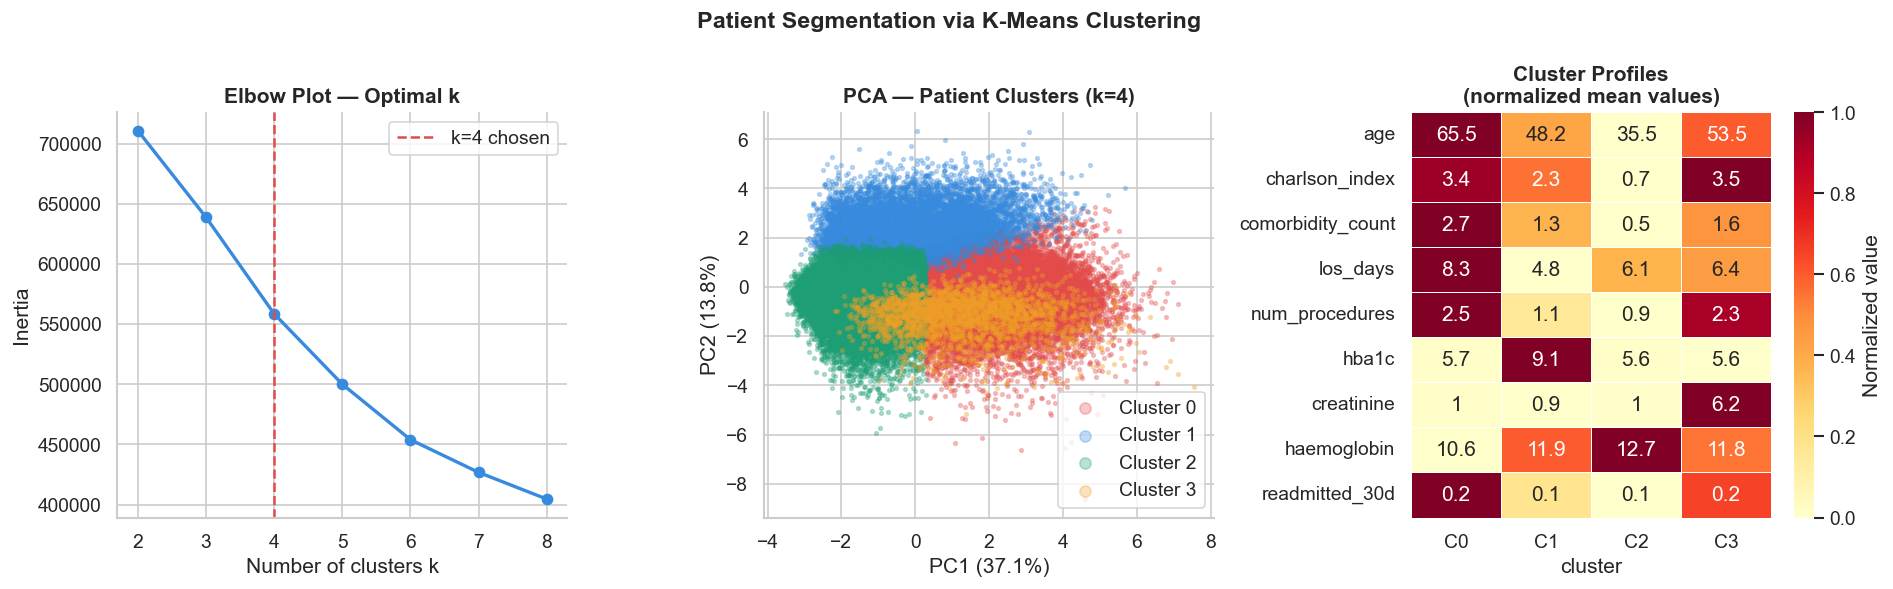


Cluster summary:
           age  charlson_index  los_days  readmitted_30d  total_cost
cluster                                                             
0        65.52            3.37      8.27            0.20   140844.57
1        48.18            2.28      4.84            0.09    32798.80
2        35.52            0.75      6.12            0.07    72116.97
3        53.46            3.53      6.37            0.15    90100.54


In [62]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── K-Means on clinical profile ───────────────────────────────────────────────
clust_cols = ['age','charlson_index','comorbidity_count','los_days',
              'num_procedures','hba1c','creatinine','haemoglobin']

clust_df = df[clust_cols + ['readmitted_30d','ward_type','total_cost']].dropna()
X_cl = StandardScaler().fit_transform(clust_df[clust_cols])

# Elbow plot
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='#378ADD', lw=2)
axes[0].axvline(4, color='#E24B4A', lw=1.5, linestyle='--', label='k=4 chosen')
axes[0].set_xlabel('Number of clusters k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot — Optimal k', fontweight='bold')
axes[0].legend()

# Fit final k=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clust_df = clust_df.copy()
clust_df['cluster'] = km4.fit_predict(X_cl)

# PCA 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cl)
cl_pal = ['#E24B4A','#378ADD','#1D9E75','#EF9F27']
for i in range(4):
    mask = clust_df['cluster'] == i
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=cl_pal[i], s=5, alpha=0.3, label=f'Cluster {i}')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA — Patient Clusters (k=4)', fontweight='bold')
axes[1].legend(markerscale=3)

# Cluster profiles
profile = clust_df.groupby('cluster')[clust_cols+['readmitted_30d']].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm.T, annot=profile.T.round(1), fmt='g',
            cmap='YlOrRd', ax=axes[2], linewidths=0.5,
            cbar_kws={'label':'Normalized value'})
axes[2].set_title('Cluster Profiles\n(normalized mean values)', fontweight='bold')
axes[2].set_xticklabels([f'C{i}' for i in range(4)])

plt.suptitle('Patient Segmentation via K-Means Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCluster summary:')
print(clust_df.groupby('cluster')[['age','charlson_index','los_days',
                                   'readmitted_30d','total_cost']]
              .mean().round(2).to_string())

## 11. Summary of Bottlenecks <a id='11'></a>

In [63]:
print('=' * 70)
print('HOSPITAL BOTTLENECK ANALYSIS — EXECUTIVE SUMMARY')
print('=' * 70)

print(f"""
DATASET
  Total admissions : {len(adm):,}
  Unique patients  : {pat['patient_id'].nunique():,}
  Hospitals        : {hosp.shape[0]}
  Date range       : {adm['admit_date'].min().date()} → {adm['admit_date'].max().date()}

BOTTLENECK 1 — CAPACITY OVERLOAD
  • Kerala & MP district hospitals: occupancy 10–11× capacity
  • NICU: 55% of stays exceed 14 days (avg 16.6d)
  • ICU:  31% of stays exceed 14 days (avg 12.9d)
  • Ward type explains 84% of LOS variance (ML)
  → Action: step-down pathways, patient diversion protocols

BOTTLENECK 2 — READMISSION QUALITY
  • System-wide 30-day readmission: {adm['readmitted_30d'].mean()*100:.1f}%
  • Perinatal: 18.6% · Cardiovascular: 16.6% (worst categories)
  • No tier advantage — private tier-1 matches govt tier-2 rates
  • Readmission RF model AUC = {cls_results['Random Forest']['auc']:.3f}
  • Top predictors: comorbidity_count, los_days, charlson_index
  → Action: discharge risk scoring, post-discharge follow-up

BOTTLENECK 3 — FINANCIAL INEFFICIENCY
  • Pharmacy top cost category: ₹347 Cr total
  • BPL subsidy coverage: only 48.4%
  • BPL avg OOP (₹49,341) nearly equal to Non-BPL (₹47,500)
  • Statistical significance confirmed (Mann-Whitney p<0.001)
  → Action: audit subsidy pipeline, generic drug procurement

ML MODELS BUILT
  1. LOS Prediction      — GBM  (R²={results['Gradient Boosting']['R2']:.3f}, MAE={results['Gradient Boosting']['MAE']:.2f}d)
  2. Readmission Risk    — RF   (AUC={cls_results['Random Forest']['auc']:.3f})
  3. Patient Segments    — KMeans k=4 (PCA-verified)
""")
print('=' * 70)

HOSPITAL BOTTLENECK ANALYSIS — EXECUTIVE SUMMARY

DATASET
  Total admissions : 120,000
  Unique patients  : 86,400
  Hospitals        : 33
  Date range       : 2015-01-01 → 2024-12-30

BOTTLENECK 1 — CAPACITY OVERLOAD
  • Kerala & MP district hospitals: occupancy 10–11× capacity
  • NICU: 55% of stays exceed 14 days (avg 16.6d)
  • ICU:  31% of stays exceed 14 days (avg 12.9d)
  • Ward type explains 84% of LOS variance (ML)
  → Action: step-down pathways, patient diversion protocols

BOTTLENECK 2 — READMISSION QUALITY
  • System-wide 30-day readmission: 11.8%
  • Perinatal: 18.6% · Cardiovascular: 16.6% (worst categories)
  • No tier advantage — private tier-1 matches govt tier-2 rates
  • Readmission RF model AUC = 0.736
  • Top predictors: comorbidity_count, los_days, charlson_index
  → Action: discharge risk scoring, post-discharge follow-up

BOTTLENECK 3 — FINANCIAL INEFFICIENCY
  • Pharmacy top cost category: ₹347 Cr total
  • BPL subsidy coverage: only 48.4%
  • BPL avg OOP (₹49,